<div style="display: flex; align-items: center;">
    <img alt="udeA logo" height="140px" src="https://github.com/freddyduitama/images/blob/master/logo.png?raw=true" style="width:107px;height:152px; margin-right: 40px;">
    <div style="text-align: center;">
        <h1><b><font color='0B5345'>Trabajo 4: Imagenes médicas</font></b></h1>
        <h2><font color='0B5345'>Luisa Fernanda Enciso - Juan Diego Caguasango</font></h2>
    </div>
</div>


## 1. Preguntas teóricas 20%


### ¿Qué es una red neuronal convolucional (CNN)?


Las redes neuronales convolucionales, conocidas como CNN, son modelos de aprendizaje profundo especialmente diseñados para trabajar con imágenes, incluyendo imágenes médicas. Se utilizan ampliamente en tareas como la detección de estructuras o la clasificación de patologías, ya que tienen la capacidad de identificar automáticamente patrones relevantes mediante un proceso llamado convolución. Estas redes están compuestas por varias capas como las capas convolucionales, de agrupamiento y densas que trabajan en conjunto para analizar la información visual y extraer las características más significativas


### ¿Qué papel juegan las capas Conv2D, Pooling, Flatten, y Dense?


Las capas Conv2D, Pooling, Flatten y Dense son elementos fundamentales en la arquitectura de las redes neuronales conjuntas permiten extraer características, reducir la dimensionalidad de los datos y, finalmente, clasificar de forma eficiente la información de entrada.

Capa Conv2D
La capa Conv2D realiza operaciones de convolución sobre los datos de entrada. Su función principal es detectar patrones espaciales como bordes, texturas o formas. Esto se logra mediante el uso de filtros que se entrenan para identificar características relevantes en distintas regiones de la imagen.

Capa de Pooling
Las capas de pooling, como el max pooling, suelen ubicarse después de las capas convolucionales. Su objetivo es reducir el tamaño espacial de los mapas de características, lo cual disminuye la carga computacional

Capa Flatten
La capa Flatten convierte los mapas de características que resultan de las capas anteriores en un vector unidimensional. Este paso es crucial porque permite conectar la parte convolucional de la red con las capas densas las cuales necesitan vectores a la entrada para funcionar correctamente.

Capa Dense
Las capas Densas, se encargan de realizar la clasificación final. Combinan las características aprendidas por las capas anteriores para generar una predicción. Son fundamentales en el proceso de toma de decisiones de la red, ya que integran toda la información extraída para dar una salida coherente.


### ¿Qué es el padding, el stride y el kernel?


El padding se refiere a la técnica de añadir píxeles alrededor de la imagen de entrada para evitar que se reduzca tras la convolución. Esta técnica es útil para mantener el tamaño original de la imagen en varias capas.

El stride indica la cantidad de píxeles que desplaza el kernel cada vez que se aplica a la imagen. Un stride mayor reduce el tamaño de salida, mientras que uno menor conserva más detalles.

El kernel, por otro lado, es una pequeña matriz que se desliza sobre la imagen de entrada para realizar la convolución. Su función principal es detectar características específicas, como bordes, texturas o patrones, en los datos visuales.


### ¿Qué significa overfitting y cómo se puede prevenir?


El overfitting es un problema importante en el aprendizaje automático que ocurre cuando un modelo aprende demasiado bien los datos de entrenamiento, hasta el punto de que pierde capacidad para generalizar a nuevos datos que no ha visto antes como es el caso de los datos de test. Esto suele pasar cuando el modelo es demasiado complejo, o cuando el conjunto de datos contiene ruido.

Para evitar el overfitting, una de las formas es balancear las clases del conjunto de datos, de modo que el modelo no se sesgue a predecir siempre la clase mayoritaria. También ayuda hacer el modelo más simple, reduciendo su complejidad para que no memorice detalles innecesarios. Además, otras estrategias incluyen aumentar la cantidad de datos de entrenamiento, limpiar el ruido presente en los datos y aplicar técnicas como regularización o validación cruzada, que ayudan a mejorar la capacidad de generalización.


### ¿Por qué es importante la normalización de imágenes antes de entrenar un modelo CNN?


La normalización de imágenes antes de entrenar una CNN es súper importante porque ayuda a que el modelo aprenda mejor y más rápido. Básicamente, lo que hace es poner los valores de los píxeles en una escala parecida, como entre 0 y 1, para que no haya diferencias muy grandes que confundan a la red. Si no normalizamos, algunos valores pueden ser muy altos y hacer que el entrenamiento sea más difícil o que la red tarde mucho en ajustarse. Además, al normalizar, evitamos que las funciones que usa la red se saturen y dejen de funcionar bien. También, la normalización ayuda a mitigar problemas causados por variaciones en la iluminación o el contraste de color, que podrían afectar negativamente el aprendizaje. De esta manera, al tener los datos en una escala similar, el entrenamiento se vuelve más estable y rápido, porque el modelo puede converger mejor.


## 2. Implementación 60%


In [ ]:
# Manipulación numérica y tabular
import numpy as np
import pandas as pd
from collections import defaultdict

# Gráficas y visualización de resultados
import matplotlib.pyplot as plt
import seaborn as sns

# Definición de modelos y procesamiento de imágenes
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D , MaxPool2D , Flatten , Dropout , BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau

# División de datos y métricas de evaluación
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Procesamiento de imágenes
import cv2

# Manejo de carpetas y rutas
import os

import os


import random
from collections import Counter

In [ ]:
base_dir = r"D:\Luisa\imagenes\archive\Mini_DDSM_Upload"

### a. Exploración del dataset


El dataset Mini-DDSM se trata de un conjunto de datos de mamografías diseñado específicamente para investigaciones relacionadas con imágenes médicas, y en este caso particular, para la estimación automática de la edad a partir de mamogramas.

Contenido y propósito del dataset:
Origen: El Mini-DDSM proviene del Digital Database for Screening Mammography (DDSM), que es un repositorio más amplio y conocido de imágenes mamográficas.

Problema con el DDSM original: Las imágenes de alta resolución del DDSM original solo pueden ser accedidas con un software que actualmente está dañado o no funciona correctamente.

Solución: Los autores usaron un web crawler para descargar miniaturas (thumbnails) de las imágenes mamográficas y los metadatos asociados, incluyendo la edad de las pacientes, para crear este nuevo subconjunto llamado Mini-DDSM.

Aplicación: Con esas imágenes y la edad de las pacientes, entrenaron un modelo de aprendizaje automático (Random Forest Regressor) para predecir la edad de una persona a partir de su mamografía.


- **Formato de los datos**


In [ ]:
class_names = ["Normal", "Cancer", "Benign"]

for class_name in class_names:
    folder_path = os.path.join(base_dir, class_name)
    extensiones = set()

    if not os.path.exists(folder_path):
        print(f"[ADVERTENCIA] Carpeta no encontrada: {folder_path}")
        continue

    for file in os.listdir(folder_path):
        ext = os.path.splitext(file)[1]
        extensiones.add(ext.lower())

    print(f"Carpeta: {class_name} - Extensión: {extensiones}")


Carpeta: Normal - Extensión: {'.png'}
Carpeta: Cancer - Extensión: {'.png'}
Carpeta: Benign - Extensión: {'.png'}


- **Cantidad de datos**


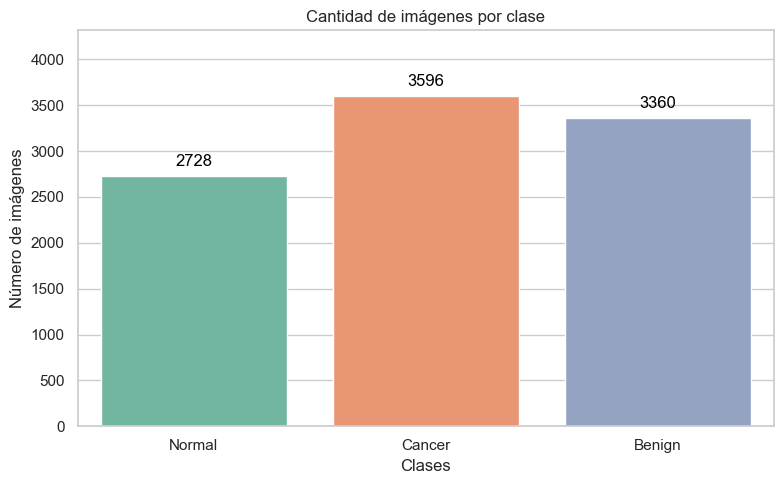

In [ ]:
class_names = ["Normal", "Cancer", "Benign"]
image_counts = {}

for class_name in class_names:
    folder_path = os.path.join(base_dir, class_name)
    if not os.path.exists(folder_path):
        print(f"Carpeta no encontrada: {folder_path}")
        continue
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    image_counts[class_name] = len(files)

df = pd.DataFrame({
    'Clase': list(image_counts.keys()),
    'Cantidad': list(image_counts.values())
})

plt.figure(figsize=(8, 5))
sns.set(style="whitegrid")

barplot = sns.barplot(x='Clase', y='Cantidad', hue='Clase', data=df, palette='Set2', legend=False)

# Eliminar leyenda manualmente por si acaso
if barplot.get_legend() is not None:
    barplot.get_legend().remove()

# Etiquetas con valores
for p in barplot.patches:
    height = p.get_height()
    barplot.annotate(f'{int(height)}',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom',
                     fontsize=12, color='black',
                     xytext=(0, 5),
                     textcoords='offset points')

plt.title("Cantidad de imágenes por clase")
plt.xlabel("Clases")
plt.ylabel("Número de imágenes")
plt.ylim(0, max(df['Cantidad']) * 1.2)
plt.tight_layout()
plt.show()

- **Inspección Visual**


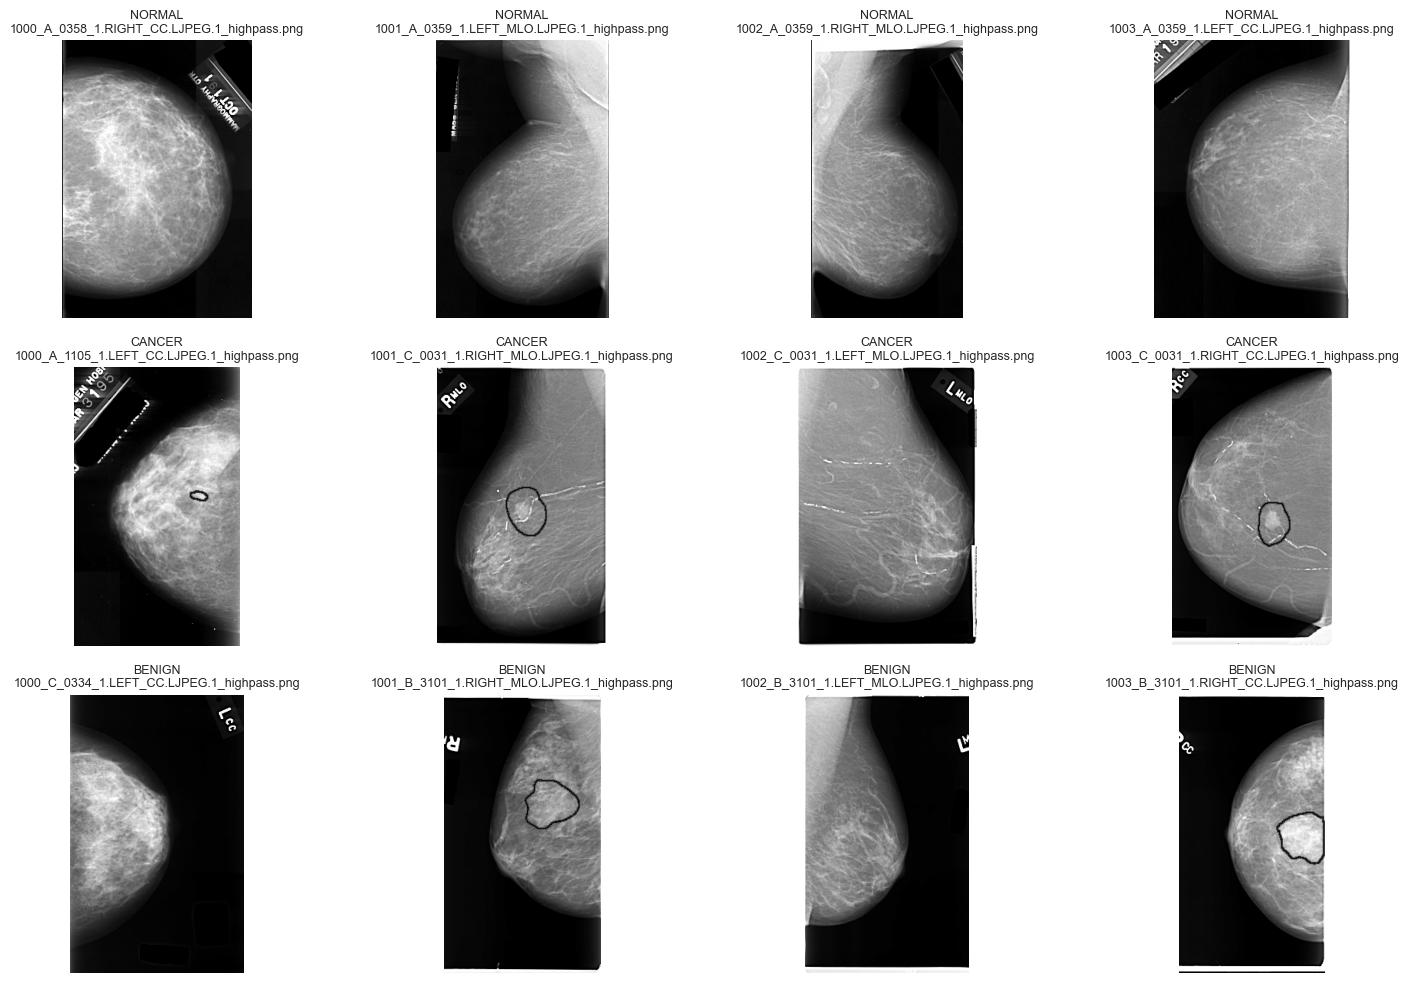

In [ ]:
normal_folder = os.path.join(base_dir, "Normal")
cancer_folder = os.path.join(base_dir, "Cancer")
benign_folder = os.path.join(base_dir, "Benign")

# Obtener archivos
normal_files = os.listdir(normal_folder)
cancer_files = os.listdir(cancer_folder)
benign_files = os.listdir(benign_folder)

# Número de imágenes a mostrar por clase
n_images = 4

# Diccionario de clases y sus rutas
classes = {
    "Normal": (normal_folder, normal_files),
    "Cancer": (cancer_folder, cancer_files),
    "Benign": (benign_folder, benign_files)
}

# Crear figura
plt.figure(figsize=(4 * n_images, 10))

# Iterar sobre cada clase y graficar
for row_idx, (class_name, (folder, file_list)) in enumerate(classes.items()):
    for col_idx, img_name in enumerate(file_list[:n_images]):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        ax_idx = row_idx * n_images + col_idx + 1
        plt.subplot(len(classes), n_images, ax_idx)
        plt.imshow(img, cmap="gray")
        plt.title(f"{class_name.upper()}\n{img_name}", fontsize=9)
        plt.axis("off")

plt.tight_layout()
plt.show()

- **Tamaño de Imagen**


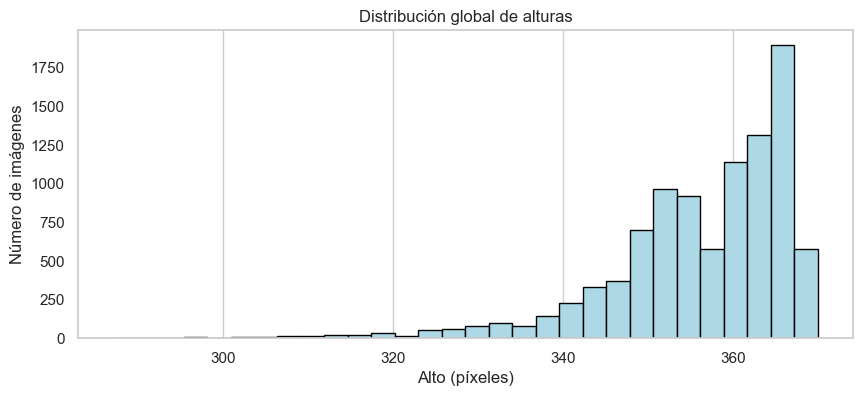

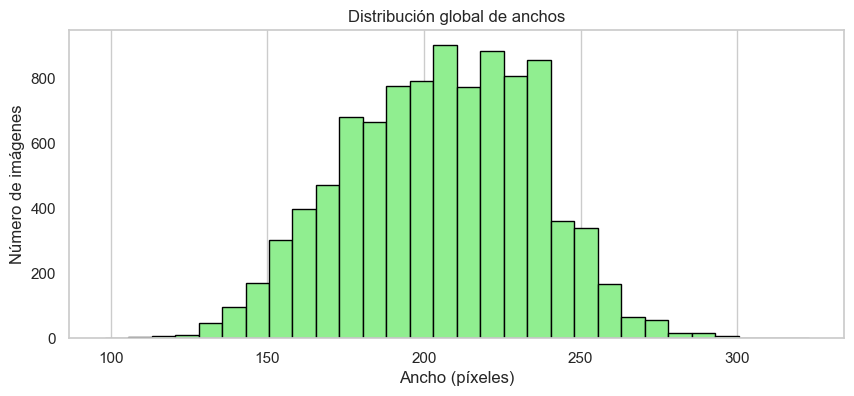

In [ ]:
class_names = ["Normal", "Benign", "Cancer"]

heights = []
widths = []

for class_name in class_names:
    folder_path = os.path.join(base_dir, class_name)
    if not os.path.exists(folder_path):
        print(f"Carpeta no encontrada: {folder_path}")
        continue
    for file in os.listdir(folder_path):
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            img_path = os.path.join(folder_path, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                h, w = img.shape
                heights.append(h)
                widths.append(w)

# Histograma alturas
plt.figure(figsize=(10,4))
plt.hist(heights, bins=30, color="lightblue", edgecolor="black")
plt.title("Distribución global de alturas")
plt.xlabel("Alto (píxeles)")
plt.ylabel("Número de imágenes")
plt.grid(axis="y")
plt.show()

# Histograma anchos
plt.figure(figsize=(10,4))
plt.hist(widths, bins=30, color="lightgreen", edgecolor="black")
plt.title("Distribución global de anchos")
plt.xlabel("Ancho (píxeles)")
plt.ylabel("Número de imágenes")
plt.grid(axis="y")
plt.show()

- **Intensidades**


In [ ]:
# Clases
class_names = ["Normal", "Benign", "Cancer"]
sample_size = 100  # Número de imágenes a analizar por clase

mean_intensities = []
std_intensities = []

for class_name in class_names:
    folder_path = os.path.join(base_dir, class_name)
    if not os.path.exists(folder_path):
        print(f"[ADVERTENCIA] Carpeta no encontrada: {folder_path}")
        continue

    # Lista de archivos de imagen válidos
    files = [f for f in os.listdir(folder_path) if f.lower().endswith((".png"))]
    sampled_files = random.sample(files, min(sample_size, len(files)))

    for file in sampled_files:
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        mean_intensities.append(np.mean(img))
        std_intensities.append(np.std(img))

print("\n Intensidades")

if np.std(mean_intensities) < 5:
    print("Las intensidades son razonablemente homogéneas.")
else:
    print("Hay variación en brillo/contraste. Se debe hacer normalización.")


 Intensidades
Hay variación en brillo/contraste. Se debe hacer normalización.


- **Organización de los datos**

1. Redimensionar


In [ ]:
import os
import cv2
import numpy as np

labels = ["Normal", "Benign", "Cancer"]
label_map = {"Normal": 0, "Benign": 1, "Cancer": 2}
img_size = 150

def get_training_data(data_dir):
    data = []
    valid_extensions = (".jpeg", ".jpg", ".png")
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = label_map[label]  # <-- asignación explícita

        if not os.path.exists(path):
            print(f"Carpeta no encontrada: {path}")
            continue

        files = [f for f in os.listdir(path) if f.lower().endswith(valid_extensions)]

        for img in files:
            try:
                img_path = os.path.join(path, img)
                img_arr = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                if img_arr is None:
                    print(f"No se pudo leer: {img_path}")
                    continue

                resized_arr = cv2.resize(img_arr, (img_size, img_size))
                data.append([resized_arr, class_num])
            except Exception as e:
                print(f"Error procesando {img}: {e}")

    return np.array(data, dtype=object)


In [ ]:
dataset_r = get_training_data(base_dir)


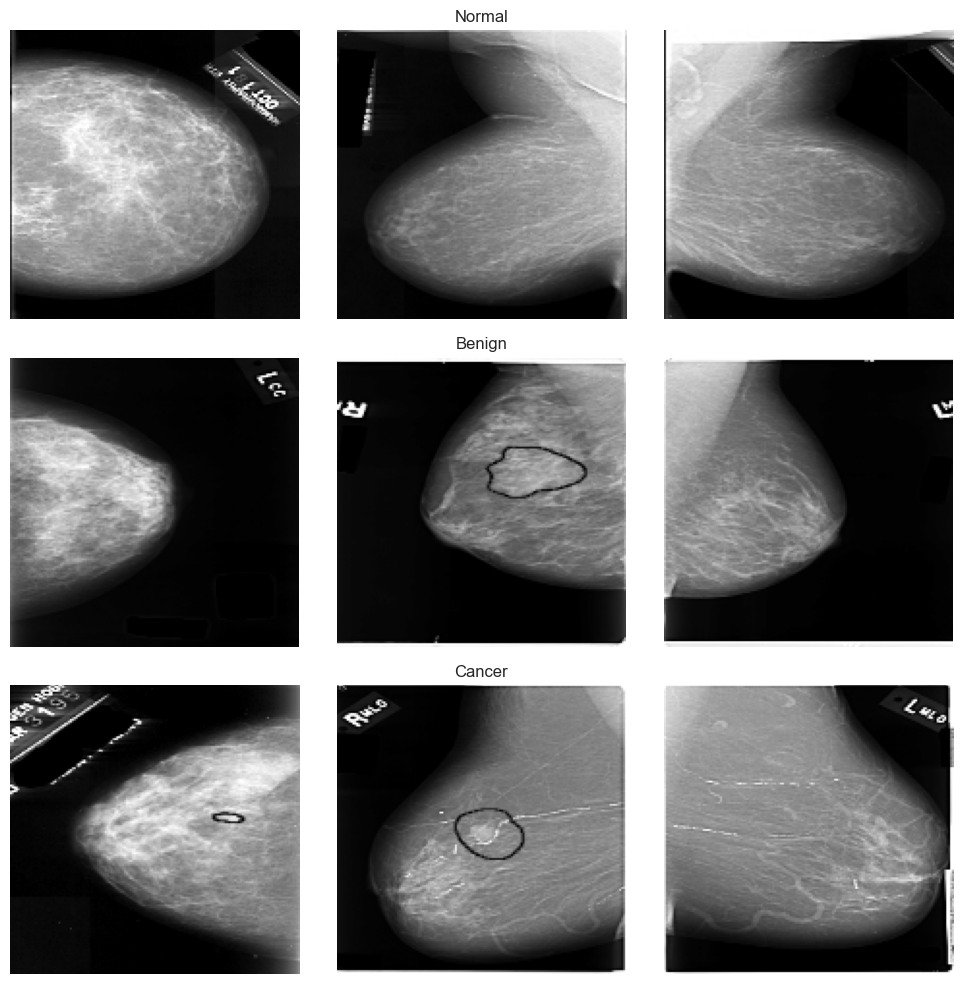

In [ ]:
# Crear figura 3x3
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

# Por cada clase
for class_idx in range(3):
    # Filtra imágenes de esa clase
    images_in_class = [item[0] for item in dataset_r if item[1] == class_idx]

    # Tomar las 3 primeras imágenes (o puedes usar random.sample)
    for i in range(3):
        img = images_in_class[i]
        img = img / 255.0  # normalización si no la hiciste antes

        ax = axes[class_idx, i]
        ax.imshow(img, cmap='gray')
        if i == 1:
            ax.set_title(labels[class_idx], fontsize=12)
        ax.axis('off')

plt.tight_layout()
plt.show()

* **Organización de datos**

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Separar imágenes y etiquetas
X = np.array([item[0] for item in dataset_r])
y = np.array([item[1] for item in dataset_r])

# Asegurar tipo float32
X = X.astype(np.float32)

# Normalización Z-score global
mean = np.mean(X)
std = np.std(X)
X_norm = (X - mean) / std

# Añadir canal si son grises
X_norm = np.expand_dims(X_norm, axis=-1)  # (N, 150, 150, 1)

# División entrenamiento-validación (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_norm, y, test_size=0.2, random_state=42, stratify=y
)


### b. Análisis de la red neuronal


In [ ]:
from tensorflow.keras import layers, models

img_size = 150
model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(img_size,
img_size, 1)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(3, activation='softmax'))
# Compilar el modelo
model.compile(optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])
# Mostrar resumen del modelo
model.summary()

### ¿Cuántas capas tiene y de qué tipo?

**El modelo tiene 5 capas principales:**

1. Capas convolucionales:
   - Conv2D con 32 filtros de tamaño 3x3 y activación ReLU.  
     Se aplica a imágenes de entrada de tamaño 150x150x1 (el 1 es por la escala de grises).
   - Conv2D con 64 filtros de tamaño 3x3 y activación ReLU.

2. Capa de aplanamiento:
   - Flatten. Convierte los mapas de características en un vector 1D para conectarse con las capas densas.

3. Capas densas:
   - Dense con 64 neuronas y activación ReLU.
   - Dense con 3 neuronas y activación softmax (para clasificación en 3 clases).



### ¿Qué tipo de kernels y padding se utilizan? ¿Tiene capas de pooling?  ¿Cuántos parámetros tiene? 

- Kernels: tamaño 3x3 en ambas capas convolucionales.
- Padding: tipo 'valid' (valor predeterminado). No se añade relleno, por lo que el tamaño de la imagen se reduce después de cada convolución.
- Pooling: no se usan capas de pooling.
- Total de parámetros: 87,329,411 (333.14 MB).

### ¿Qué función de activación y de pérdida utiliza?

- Funciones de activación:
  - ReLU en las capas ocultas.
  - Softmax en la capa de salida.

- Función de pérdida:
  - sparse_categorical_crossentropy (etiquetas enteras, no one-hot).

- Optimizador:
  - Adam.

### ¿Es una red para clasificación binaria o multiclase?

- Clasificación multiclase (3 clases posibles), lo cual se evidencia en la capa densa final con 3 neuronas y activación softmax.


### c. Entrenamiento y evaluación


In [ ]:
import time

start_time = time.time()

from tensorflow.keras import layers, models
img_size = 150
model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(img_size,
img_size, 1)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(3, activation='softmax'))
# Compilar el modelo
model.compile(optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])
# Mostrar resumen del modelo
model.summary()
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2,
batch_size=32)

# ======= FIN DEL ENTRENAMIENTO =======
end_time = time.time()
time_1red = end_time - start_time
print(f"Tiempo de ejecución: {end_time - start_time:.2f} segundos")

C:\Users\luisa\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 146, 146, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1364224)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    87,310,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,329,411 (333.14 MB)

 Trainable params: 87,329,411 (333.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 278s 1s/step - accuracy: 0.4594 - loss: 4.3620 - val_accuracy: 0.5884 - val_loss: 0.8295
Epoch 2/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 269s 1s/step - accuracy: 0.7582 - loss: 0.5907 - val_accuracy: 0.6123 - val_loss: 0.8224
Epoch 3/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.9366 - loss: 0.2012 - val_accuracy: 0.6445 - val_loss: 1.0632
Epoch 4/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 266s 1s/step - accuracy: 0.9914 - loss: 0.0363 - val_accuracy: 0.6239 - val_loss: 1.4972
Epoch 5/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 266s 1s/step - accuracy: 0.9989 - loss: 0.0088 - val_accuracy: 0.6374 - val_loss: 1.5938
Epoch 6/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.6226 - val_loss: 1.8716
Epoch 7/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.9996 - loss: 0.0013 - val_accuracy: 0.6400 - val_loss: 2.0206
Epoch 8/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 291s 2s/step - accuracy: 1.0000 - loss: 2.6982e-04 - val_

- **Análisis del modelo entrenado**


In [ ]:
total_params1 = model.count_params()
print(f"Cantidad total de parámetros: {total_params1}")


Cantidad total de parámetros: 87329411


In [ ]:
loss1, accuracy1 = model.evaluate(X_val, y_val)
print(f"Loss (pérdida): {loss1:.4f}")
print(f"Accuracy (precisión): {accuracy1*100:.2f}")


61/61 ━━━━━━━━━━━━━━━━━━━━ 13s 220ms/step - accuracy: 0.6319 - loss: 2.1367
Loss (pérdida): 2.1984
Accuracy (precisión): 63.91


* **Evolución de las métricas por época**

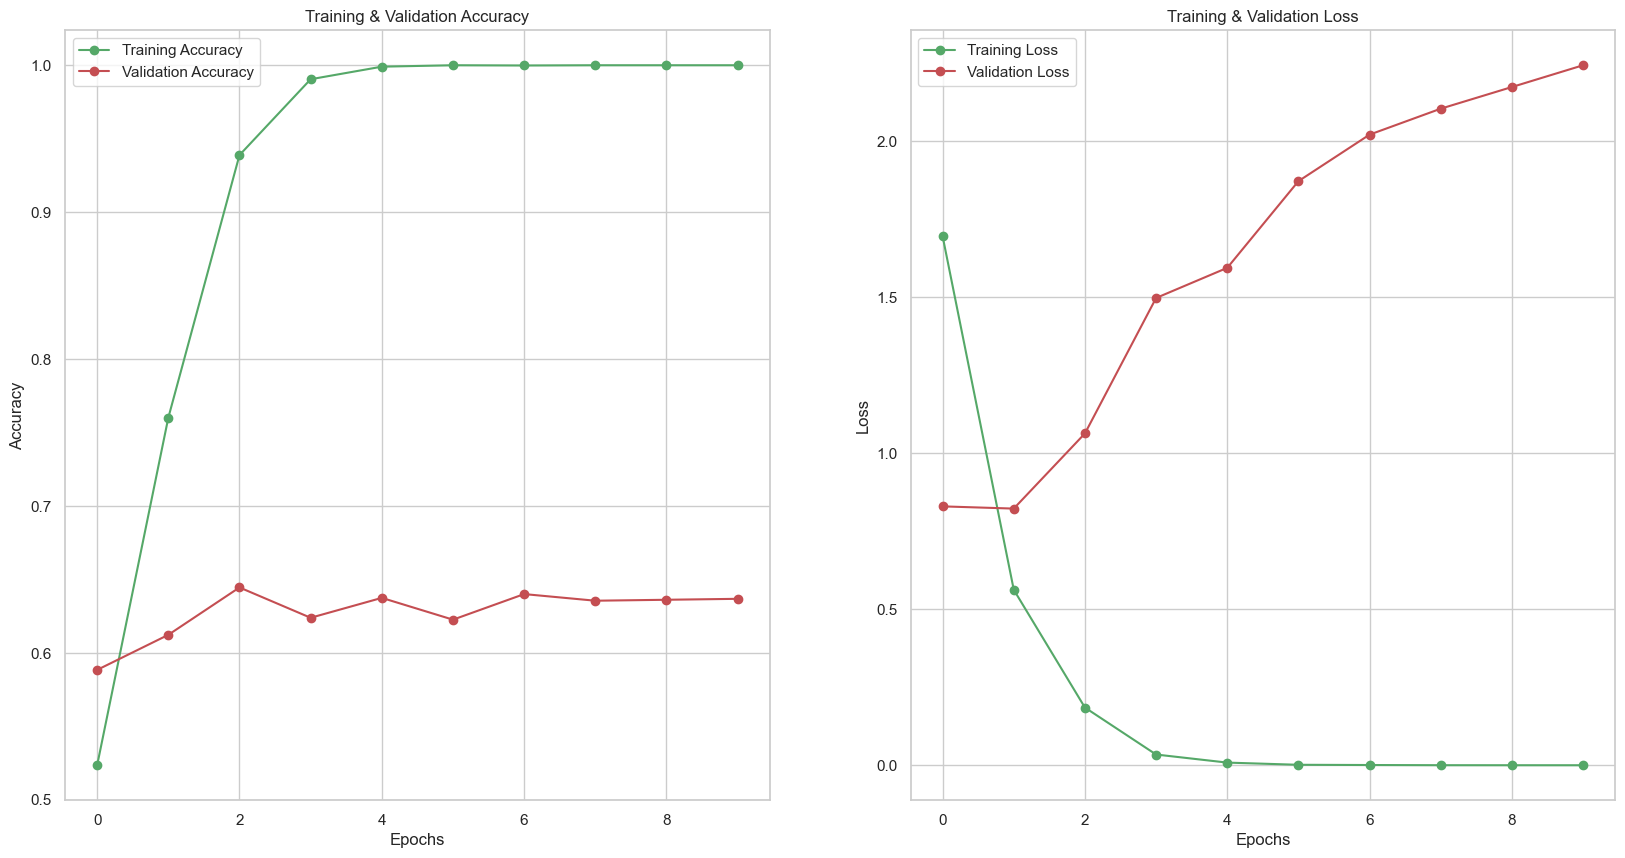

In [ ]:

fig , ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
epochs = range(len(train_acc))
fig.set_size_inches(20,10)

ax[0].plot(epochs , train_acc , 'go-' , label = 'Training Accuracy')
ax[0].plot(epochs , val_acc , 'ro-' , label = 'Validation Accuracy')
ax[0].set_title('Training & Validation Accuracy')
ax[0].legend()
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Accuracy")

ax[1].plot(epochs , train_loss , 'g-o' , label = 'Training Loss')
ax[1].plot(epochs , val_loss , 'r-o' , label = 'Validation Loss')
ax[1].set_title('Training & Validation Loss')
ax[1].legend()
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Loss")
plt.show()


* **Reporte de clasificación**

In [ ]:
# Obtener probabilidades (una probabilidad por clase para cada muestra)
probabilities = model.predict(X_val)

# Convertir a clases predichas (índice con mayor probabilidad)
predictions = np.argmax(probabilities, axis=1)

print(classification_report(y_val, predictions, target_names = ['Normal (Class 0)','Benign (Class 1)', 'Cancer (Class 2)']))

61/61 ━━━━━━━━━━━━━━━━━━━━ 13s 213ms/step
                  precision    recall  f1-score   support

Normal (Class 0)       0.70      0.73      0.71       546
Benign (Class 1)       0.62      0.60      0.61       672
Cancer (Class 2)       0.61      0.61      0.61       719

        accuracy                           0.64      1937
       macro avg       0.64      0.65      0.64      1937
    weighted avg       0.64      0.64      0.64      1937



* **Matriz de confusión**

61/61 ━━━━━━━━━━━━━━━━━━━━ 13s 206ms/step


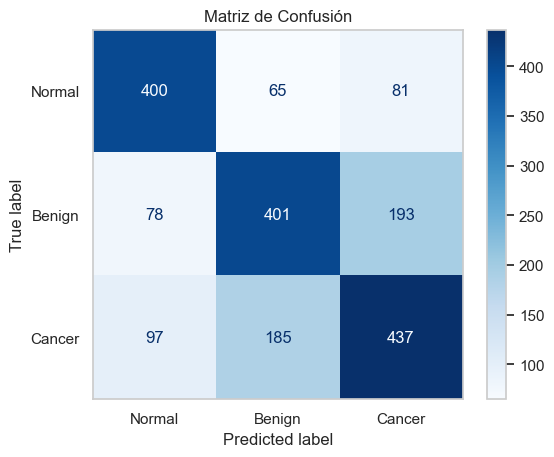

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Primero predecimos las etiquetas para el conjunto de validación
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)

# Luego construimos la matriz de confusión
cm = confusion_matrix(y_val, y_pred_classes)

# Etiquetas de clase
labels = ["Normal", "Benign", "Cancer"]

# Mostrar matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusión")
plt.grid(False)
plt.show()



* **Clases predichas**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Asegúrate de tener tus etiquetas así:
labels = ["Normal", "Benign", "Cancer"]

# Comparar predicciones con etiquetas verdaderas
correct = np.nonzero(predictions == y_val)[0]
incorrect = np.nonzero(predictions != y_val)[0]

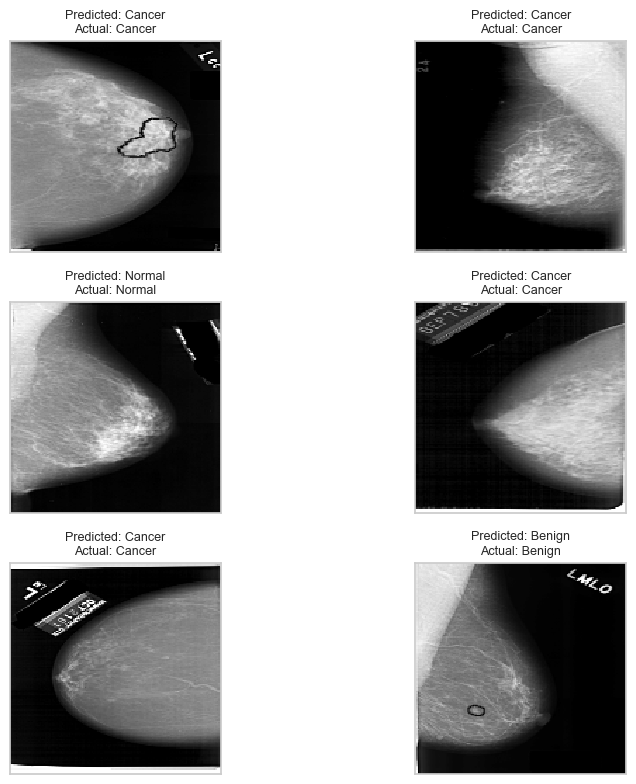

In [ ]:
# Mostrar las primeras 6 predicciones incorrectas
plt.figure(figsize=(10, 8))
for i, c in enumerate(correct[:6]):
    plt.subplot(3, 2, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_val[c].reshape(150, 150), cmap="gray", interpolation='none')

    pred_label = labels[predictions[c]]
    true_label = labels[y_val[c]]
    plt.title(f"Predicted: {pred_label}\nActual: {true_label}", fontsize=9)

plt.tight_layout()
plt.show()

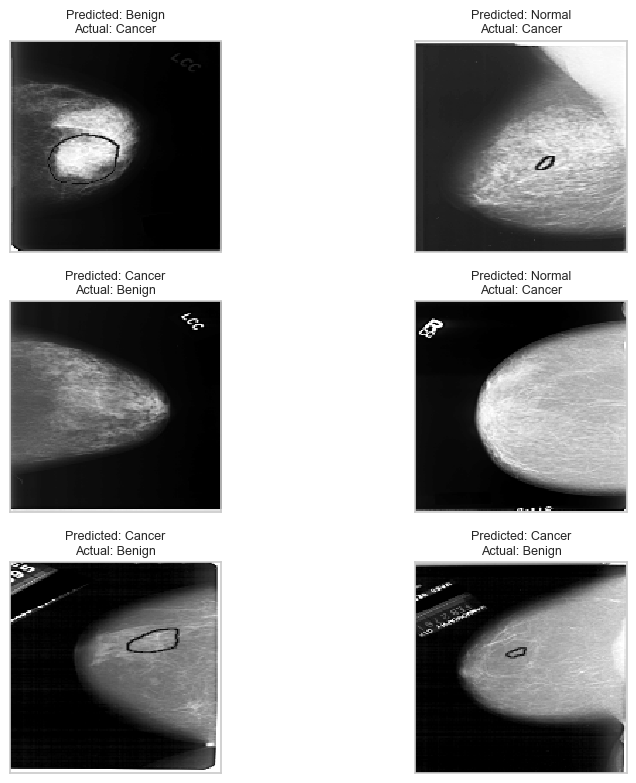

In [ ]:
# Mostrar las primeras 6 predicciones incorrectas
plt.figure(figsize=(10, 8))
for i, c in enumerate(incorrect[:6]):
    plt.subplot(3, 2, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_val[c].reshape(150, 150), cmap="gray", interpolation='none')

    pred_label = labels[predictions[c]]
    true_label = labels[y_val[c]]
    plt.title(f"Predicted: {pred_label}\nActual: {true_label}", fontsize=9)

plt.tight_layout()
plt.show()


### Analisis  resultados obtenidos.

Durante el entrenamiento de la red neuronal convolucional dada en el punto 2 , se observó un comportamiento bastante marcado de sobreajuste. El modelo alcanzó rápidamente una precisión del 100% sobre los datos de entrenamiento, lo cual se puede evidenciar en la curva de entrenamiento, donde ya desde la época 3 se logra ese valor. Esto indica que el modelo aprendió perfectamente las características presentes en el conjunto de entrenamiento. Sin embargo, la precisión en el conjunto de validación se mantuvo alrededor del 63.7%, sin mostrar mejoras significativas a medida que avanzaban las épocas. Además, la pérdida en validación comenzó a aumentar progresivamente desde las primeras épocas, mientras que la pérdida en entrenamiento descendía hasta valores cercanos a cero. Esto confirma que el modelo no está generalizando bien a datos nuevos.

Al evaluar el desempeño del modelo mediante el reporte de clasificación, se observa que para la clase Normal (Clase 0), la precisión fue de 0.70, el recall de 0.73 y el F1-score de 0.71, lo cual representa el mejor desempeño entre las tres clases. Para la clase Benign (Clase 1), el modelo obtuvo una precisión de 0.62 y un F1-score de 0.61, mientras que en la clase Cancer (Clase 2), la precisión fue de 0.61, con un F1-score igualmente de 0.61. La precisión global del modelo fue de 64%, y tanto la media ponderada como la media macro de las métricas se mantuvieron en torno a 0.64. Estos resultados refuerzan la idea de que el modelo no está diferenciando bien entre las clases, especialmente en las más críticas como el cáncer, donde se esperaría una mayor sensibilidad.

Una de las causas principales de este sobreajuste podría estar relacionada con la complejidad excesiva del modelo. La arquitectura utilizada cuenta con más de 87 millones de parámetros, lo cual es un número muy alto para un problema de clasificación que, por lo que se observa, no parece requerir tanta capacidad. Es probable que el modelo sea demasiado complejo en relación con el tamaño y la variabilidad del conjunto de datos disponible. Además, en este primer entrenamiento no se aplicaron técnicas de regularización como Dropout, ni se implementó aumento de datos (data augmentation), lo que podría haber ayudado a mejorar la generalización del modelo.

Para abordar este problema, se podrían aplicar varias estrategias. En primer lugar, sería recomendable reducir la cantidad de filtros en las capas convolucionales o incluso simplificar la arquitectura eliminando alguna de las capas. También se podría añadir Dropout en las capas densas o convolucionales, para evitar que el modelo se adapte demasiado a los datos de entrenamiento.

### d. Modificación: añadir capas de pooling


In [ ]:
import time

start_time = time.time()

from tensorflow.keras import layers, models
img_size = 150
model2 = models.Sequential()
model2.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 1)))
model2.add(layers.MaxPool2D((2,2), strides=2, padding='same'))
model2.add(layers.Conv2D(64, (3,3), activation='relu'))
model2.add(layers.MaxPool2D((2,2), strides=2, padding='same'))
model2.add(layers.Flatten())
model2.add(layers.Dense(64, activation='relu'))
model2.add(layers.Dense(3, activation='softmax'))

# Compilar el modelo
model2.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

# Mostrar resumen del modelo
model2.summary()

# Entrenamiento
history2 = model2.fit(X_train, y_train, epochs=10,  validation_data=(X_val, y_val), batch_size=32)

# Tiempo de ejecución
end_time = time.time()
time_2red = end_time - start_time
print(f"Tiempo de ejecución: {time_2red:.2f} segundos")

C:\Users\luisa\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │     5,308,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,327,491 (20.32 MB)

 Trainable params: 5,327,491 (20.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 55s 218ms/step - accuracy: 0.4280 - loss: 1.2800 - val_accuracy: 0.5787 - val_loss: 0.8665
Epoch 2/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 54s 221ms/step - accuracy: 0.6227 - loss: 0.7985 - val_accuracy: 0.6319 - val_loss: 0.7683
Epoch 3/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 55s 225ms/step - accuracy: 0.6988 - loss: 0.6645 - val_accuracy: 0.6603 - val_loss: 0.7472
Epoch 4/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 54s 221ms/step - accuracy: 0.7981 - loss: 0.4800 - val_accuracy: 0.6660 - val_loss: 0.7518
Epoch 5/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 54s 223ms/step - accuracy: 0.8965 - loss: 0.2852 - val_accuracy: 0.6882 - val_loss: 0.9625
Epoch 6/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 53s 217ms/step - accuracy: 0.9512 - loss: 0.1483 - val_accuracy: 0.6809 - val_loss: 1.0797
Epoch 7/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 51s 211ms/step - accuracy: 0.9815 - loss: 0.0688 - val_accuracy: 0.6892 - val_loss: 1.4351
Epoch 8/10
243/243 ━━━━━━━━━━━━━━━━━━━━ 52s 213ms/step - accuracy: 0.9895 - loss: 0

- **Análisis del modelo entrenado**

In [ ]:
total_params2 = model2.count_params()
print(f"Cantidad total de parámetros: {total_params2}")

Cantidad total de parámetros: 5327491


In [ ]:
loss2, accuracy2 = model2.evaluate(X_val, y_val)
print(f"Loss (pérdida): {loss2:.4f}")
print(f"Accuracy (precisión): {accuracy2*100:.2f}")

61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.6696 - loss: 1.7017
Loss (pérdida): 1.7308
Accuracy (precisión): 66.80


* **Evolución de las métricas por época**

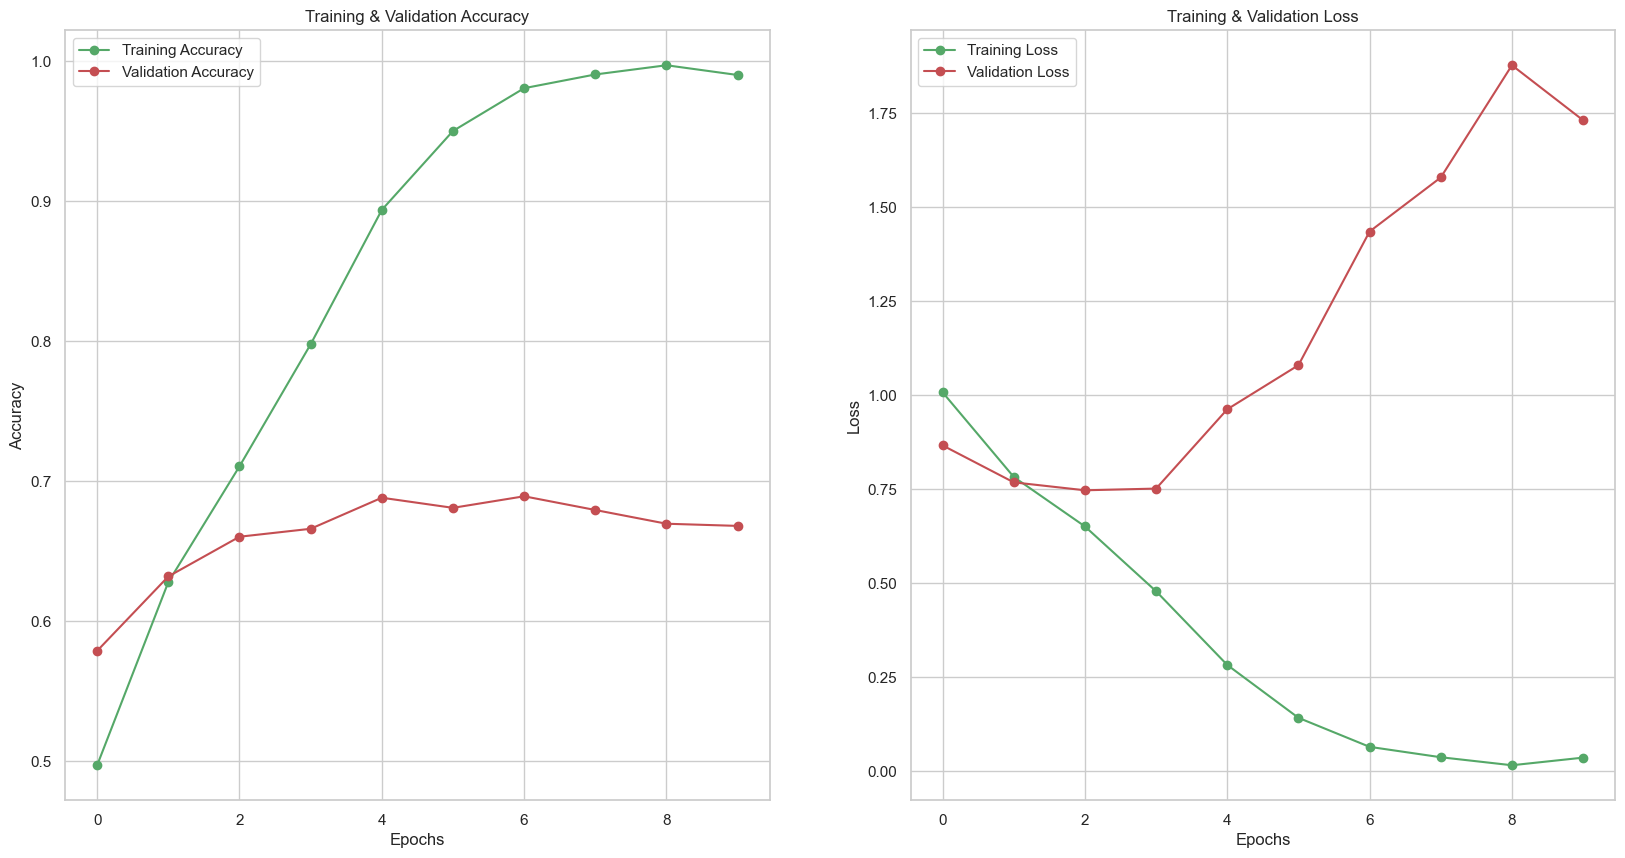

In [ ]:
fig , ax = plt.subplots(1,2)
train_acc = history2.history['accuracy']
train_loss = history2.history['loss']
val_acc = history2.history['val_accuracy']
val_loss = history2.history['val_loss']
epochs = range(len(train_acc))
fig.set_size_inches(20,10)

ax[0].plot(epochs , train_acc , 'go-' , label = 'Training Accuracy')
ax[0].plot(epochs , val_acc , 'ro-' , label = 'Validation Accuracy')
ax[0].set_title('Training & Validation Accuracy')
ax[0].legend()
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Accuracy")

ax[1].plot(epochs , train_loss , 'g-o' , label = 'Training Loss')
ax[1].plot(epochs , val_loss , 'r-o' , label = 'Validation Loss')
ax[1].set_title('Training & Validation Loss')
ax[1].legend()
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Loss")
plt.show()

* **Reporte de clasificación**

In [ ]:
# Obtener probabilidades (una probabilidad por clase para cada muestra)
probabilities = model2.predict(X_val)

# Convertir a clases predichas (índice con mayor probabilidad)
predictions2 = np.argmax(probabilities, axis=1)

print(classification_report(y_val, predictions2, target_names = ['Normal (Class 0)','Benign (Class 1)', 'Cancer (Class 2)']))

61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step
                  precision    recall  f1-score   support

Normal (Class 0)       0.78      0.77      0.78       546
Benign (Class 1)       0.62      0.61      0.61       672
Cancer (Class 2)       0.63      0.65      0.64       719

        accuracy                           0.67      1937
       macro avg       0.68      0.67      0.68      1937
    weighted avg       0.67      0.67      0.67      1937



* **Matriz de confusión**

61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step


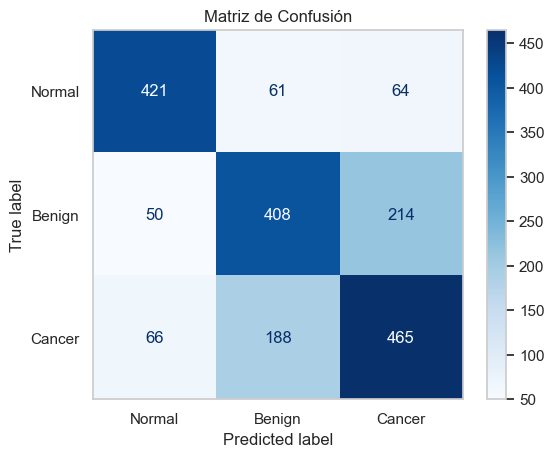

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Primero predecimos las etiquetas para el conjunto de validación
y_pred = model2.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)

# Luego construimos la matriz de confusión
cm = confusion_matrix(y_val, y_pred_classes)

# Etiquetas de clase
labels = ["Normal", "Benign", "Cancer"]

# Mostrar matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusión")
plt.grid(False)
plt.show()

* **Clases predichas**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Asegúrate de tener tus etiquetas así:
labels = ["Normal", "Benign", "Cancer"]

# Comparar predicciones con etiquetas verdaderas
correct = np.nonzero(predictions == y_val)[0]
incorrect = np.nonzero(predictions != y_val)[0]

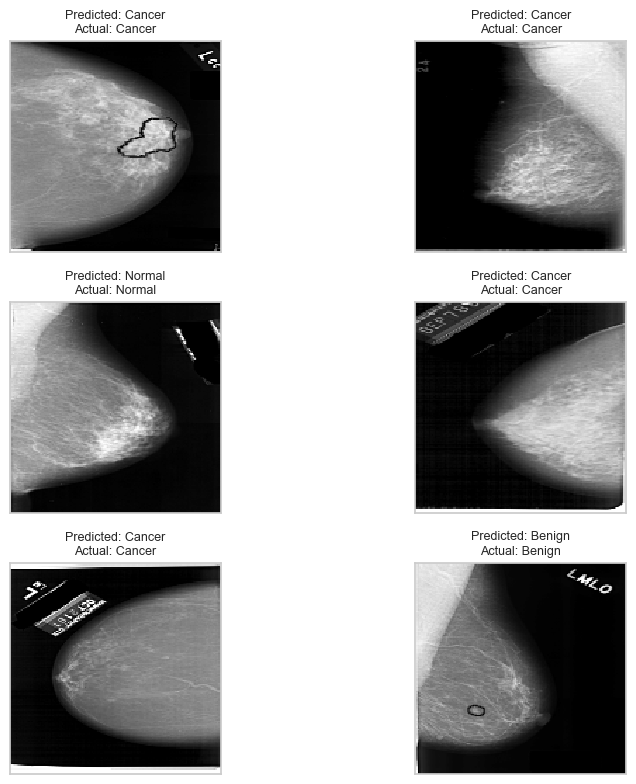

In [ ]:
# Mostrar las primeras 6 predicciones incorrectas
plt.figure(figsize=(10, 8))
for i, c in enumerate(correct[:6]):
    plt.subplot(3, 2, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_val[c].reshape(150, 150), cmap="gray", interpolation='none')

    pred_label = labels[predictions[c]]
    true_label = labels[y_val[c]]
    plt.title(f"Predicted: {pred_label}\nActual: {true_label}", fontsize=9)

plt.tight_layout()
plt.show()

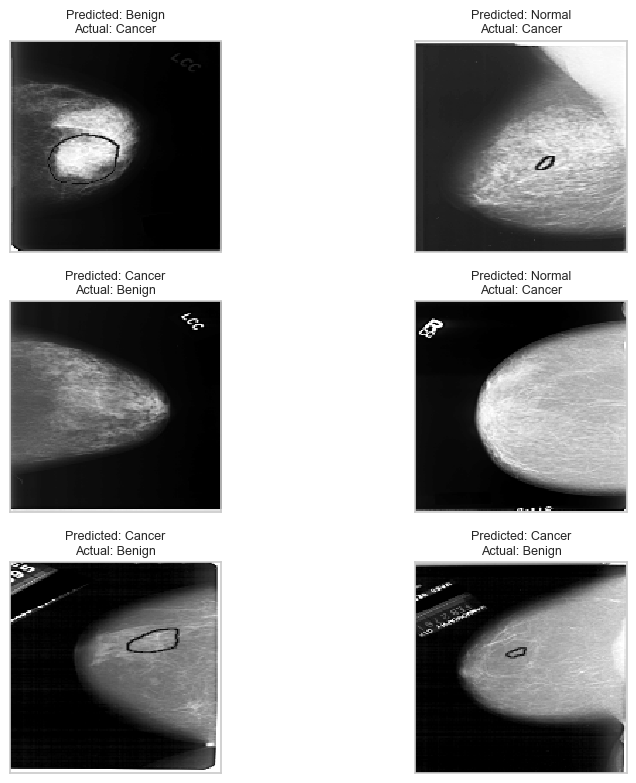

In [ ]:
# Mostrar las primeras 6 predicciones incorrectas
plt.figure(figsize=(10, 8))
for i, c in enumerate(incorrect[:6]):
    plt.subplot(3, 2, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_val[c].reshape(150, 150), cmap="gray", interpolation='none')

    pred_label = labels[predictions[c]]
    true_label = labels[y_val[c]]
    plt.title(f"Predicted: {pred_label}\nActual: {true_label}", fontsize=9)

plt.tight_layout()
plt.show()

### Analisis  resultados obtenidos.

Durante el entrenamiento de la segunda red neuronal convolucional, se volvió a notar un comportamiento de sobreajuste, aunque en menor medida comparado con la primera red. Esta nueva arquitectura es mucho más simple y eficiente, ya que incluye dos capas adicionales de MaxPooling.

El modelo tiene aproximadamente 5.33 millones de parámetros entrenables (unos 20.32 MB), lo que representa una reducción enorme frente a los más de 87 millones de la primera versión. Gracias a esta simplificación, el entrenamiento fue mucho más rápido: tomó 534.05 segundos, menos de una quinta parte del tiempo que necesitó el modelo anterior (2759.91 segundos). Esto demuestra lo beneficioso que es usar modelos más livianos y adecuados a la complejidad real del problema.

En las primeras épocas, el modelo logró una precisión muy alta en el conjunto de entrenamiento, llegando al 99.75% en la época 9 y con una pérdida muy baja (0.0163). Sin embargo, al evaluar el conjunto de validación, la precisión se estancó alrededor del 68-69%, y la pérdida comenzó a aumentar desde la época 6 (pasando de 1.08 a 1.88 en la época 9), lo cual es un claro síntoma de sobreajuste.

Al analizar el reporte de clasificación, la clase Normal (Clase 0) obtuvo los mejores resultados, con una precisión y F1-score de 0.78. Por otro lado, las clases Benign (Clase 1) y Cancer (Clase 2) tuvieron valores más bajos, con F1-scores cercanos a 0.61 y 0.64 respectivamente. Aunque estos resultados son un poco mejores que los del modelo anterior (que tuvo una precisión global del 64%), todavía hay espacio para mejorar, especialmente en la detección de la clase Cáncer, donde sería ideal lograr mayor sensibilidad.

Aunque la precisión final en validación fue un poco mejor que la del modelo previo , este nuevo modelo mostró una convergencia más estable y, sobre todo, entrenó mucho más rápido y con menos parámetros. Sin embargo, el aumento constante de la pérdida en validación indica que, a pesar de ser más simple, el modelo aún no logra generalizar bien.

Para reducir el sobreajuste, sería buena idea implementar técnicas de regularización como Dropout, usar aumento de datos (data augmentation)Estas estrategias podrían ayudar a que el modelo aprenda mejor y no se quede "memorizando" el conjunto de entrenamiento.

## 3. Propuesta y aplicación de mejoras 20%


* **Aumento de datos**

In [34]:
datagen = ImageDataGenerator(
    featurewise_center=False,           # No centrar el conjunto de datos completo a media 0
    samplewise_center=False,            # No centrar cada muestra individual a media 0
    featurewise_std_normalization=False,# No dividir por la desviación estándar del dataset
    samplewise_std_normalization=False, # No dividir cada muestra por su desviación estándar
    zca_whitening=False,                # No aplicar blanqueo ZCA (decorrelación de componentes)

    rotation_range=30,                  # Rotar aleatoriamente las imágenes hasta ±30 grados
    zoom_range=0.2,                     # Aplicar zoom aleatorio hasta un 20%
    width_shift_range=0.1,              # Desplazar horizontalmente hasta un 10% de la anchura
    height_shift_range=0.1,             # Desplazar verticalmente hasta un 10% de la altura
    horizontal_flip=True,               # Aplicar giros horizontales aleatorios
    vertical_flip=False                 # No aplicar giros verticales
)

# Ajustar el generador a los datos de entrenamiento
datagen.fit(X_train)


* **Entrenamiento del modelo**

In [82]:
import time
from tensorflow.keras.optimizers import RMSprop

start_time = time.time()

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

img_size = 150
model3 = models.Sequential()
model3.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 1)))
model3.add(layers.MaxPool2D((2, 2), strides=2, padding='same'))
model3.add(layers.Conv2D(64, (3, 3), activation='relu'))
# Dropout para evitar sobreajuste
model3.add(layers.Dropout(0.2))

model3.add(layers.MaxPool2D((2, 2), strides=2, padding='same'))

model3.add(layers.Flatten())
model3.add(layers.Dense(64, activation='relu'))
model3.add(layers.Dropout(0.3))

model3.add(layers.Dense(3, activation='softmax'))

opt = RMSprop(learning_rate=0.0001)
# Compilar el modelo
model3.compile(optimizer=opt,
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

# Mostrar resumen del modelo
model3.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Entrenamiento
history3 = model3.fit(X_train, y_train, batch_size=16, epochs=20, validation_data=(X_val, y_val),callbacks=[early_stop])

# Tiempo de ejecución
end_time = time.time()
time_3red = end_time - start_time
print(f"Tiempo de ejecución: {time_3red:.2f} segundos")

C:\Users\luisa\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 72, 72, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │     5,308,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,327,491 (20.32 MB)

 Trainable params: 5,327,491 (20.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
485/485 ━━━━━━━━━━━━━━━━━━━━ 77s 156ms/step - accuracy: 0.4305 - loss: 1.0485 - val_accuracy: 0.4719 - val_loss: 0.9943
Epoch 2/20
485/485 ━━━━━━━━━━━━━━━━━━━━ 72s 148ms/step - accuracy: 0.5323 - loss: 0.9150 - val_accuracy: 0.5767 - val_loss: 0.8715
Epoch 3/20
485/485 ━━━━━━━━━━━━━━━━━━━━ 74s 152ms/step - accuracy: 0.5751 - loss: 0.8618 - val_accuracy: 0.5674 - val_loss: 0.8552
Epoch 4/20
485/485 ━━━━━━━━━━━━━━━━━━━━ 71s 146ms/step - accuracy: 0.6125 - loss: 0.8087 - val_accuracy: 0.5803 - val_loss: 0.8543
Epoch 5/20
485/485 ━━━━━━━━━━━━━━━━━━━━ 71s 146ms/step - accuracy: 0.6346 - loss: 0.7692 - val_accuracy: 0.6319 - val_loss: 0.7878
Epoch 6/20
485/485 ━━━━━━━━━━━━━━━━━━━━ 72s 148ms/step - accuracy: 0.6756 - loss: 0.7156 - val_accuracy: 0.6324 - val_loss: 0.7747
Epoch 7/20
485/485 ━━━━━━━━━━━━━━━━━━━━ 75s 155ms/step - accuracy: 0.6925 - loss: 0.6904 - val_accuracy: 0.6500 - val_loss: 0.7580
Epoch 8/20
485/485 ━━━━━━━━━━━━━━━━━━━━ 79s 162ms/step - accuracy: 0.6970 - loss: 0

In [ ]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience = 2, verbose=1,factor=0.3, min_lr=0.000001)

* **Análisis del modelo de entrenamiento**

In [83]:
total_params3 = model3.count_params()
print(f"Cantidad total de parámetros: {total_params3}")

Cantidad total de parámetros: 5327491


In [84]:
loss3, accuracy3= model3.evaluate(X_val, y_val)
print(f"Loss (pérdida): {loss3:.4f}")
print(f"Accuracy (precisión): {accuracy3*100:.2f}")

61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.7047 - loss: 0.7216
Loss (pérdida): 0.7317
Accuracy (precisión): 69.28


* **Evolución de las metricas por epocas**

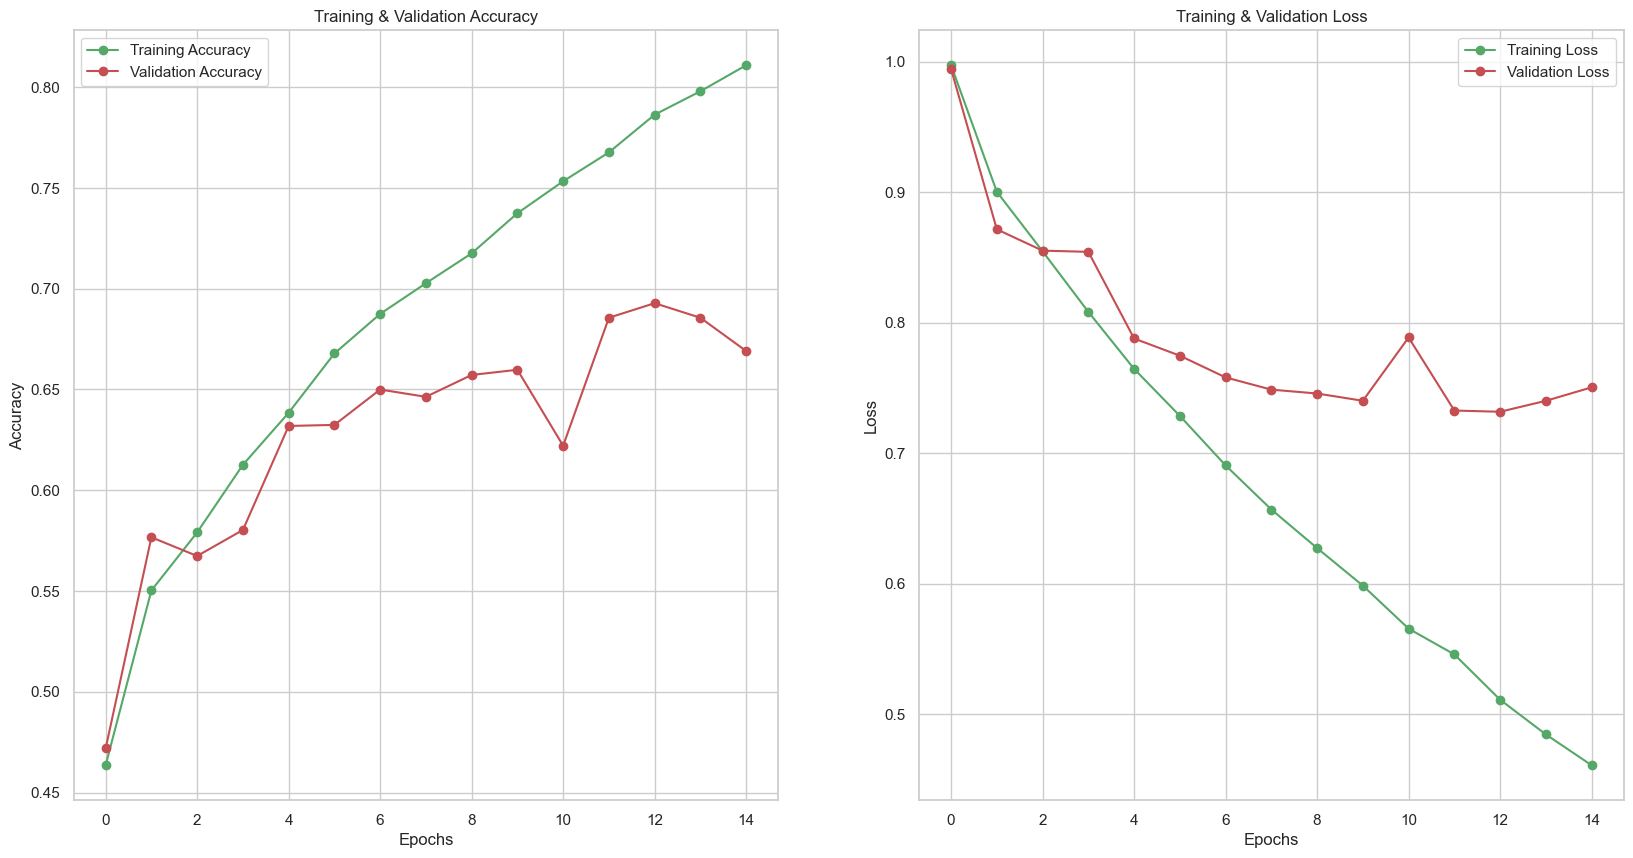

In [85]:
fig , ax = plt.subplots(1,2)
train_acc = history3.history['accuracy']
train_loss = history3.history['loss']
val_acc = history3.history['val_accuracy']
val_loss = history3.history['val_loss']
epochs = range(len(train_acc))
fig.set_size_inches(20,10)

ax[0].plot(epochs , train_acc , 'go-' , label = 'Training Accuracy')
ax[0].plot(epochs , val_acc , 'ro-' , label = 'Validation Accuracy')
ax[0].set_title('Training & Validation Accuracy')
ax[0].legend()
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Accuracy")

ax[1].plot(epochs , train_loss , 'g-o' , label = 'Training Loss')
ax[1].plot(epochs , val_loss , 'r-o' , label = 'Validation Loss')
ax[1].set_title('Training & Validation Loss')
ax[1].legend()
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Loss")
plt.show()

* **Reporte de clasificación**

In [86]:
# Obtener probabilidades (una probabilidad por clase para cada muestra)
probabilities = model3.predict(X_val)

# Convertir a clases predichas (índice con mayor probabilidad)
predictions3 = np.argmax(probabilities, axis=1)

print(classification_report(y_val, predictions3, target_names = ['Normal (Class 0)','Benign (Class 1)', 'Cancer (Class 2)']))


61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step
                  precision    recall  f1-score   support

Normal (Class 0)       0.81      0.77      0.79       546
Benign (Class 1)       0.67      0.61      0.64       672
Cancer (Class 2)       0.63      0.71      0.67       719

        accuracy                           0.69      1937
       macro avg       0.70      0.70      0.70      1937
    weighted avg       0.70      0.69      0.69      1937



* **Matriz de Confusión**

61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step


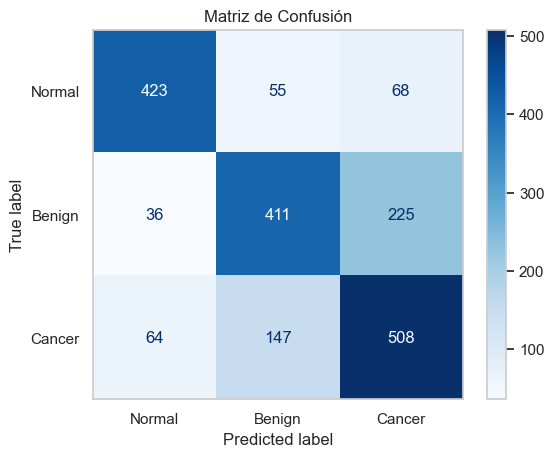

In [87]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Primero predecimos las etiquetas para el conjunto de validación
y_pred = model3.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)

# Luego construimos la matriz de confusión
cm = confusion_matrix(y_val, y_pred_classes)

# Etiquetas de clase
labels = ["Normal", "Benign", "Cancer"]

# Mostrar matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusión")
plt.grid(False)
plt.show()

### Comparación entre modelos

* **Tiempo de ejecución**

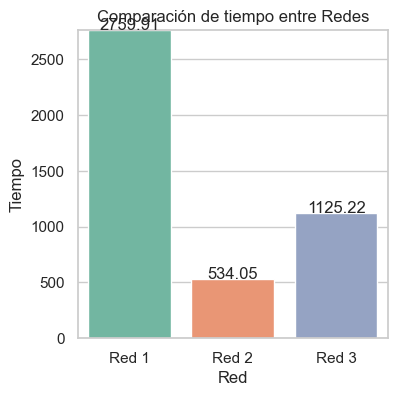

In [88]:
# Crear DataFrame para Seaborn
df = pd.DataFrame({
    'Red': ['Red 1', 'Red 2', 'Red 3'],
    'Tiempo': [time_1red, time_2red,time_3red]
})

# Gráfico de barras
plt.figure(figsize=(4, 4))
sns.barplot(data=df, x='Red', y='Tiempo', hue='Red', palette='Set2', legend=False)
plt.title('Comparación de tiempo entre Redes')
plt.ylim(0, max(df['Tiempo']) + 0.5)

# Agregar valores encima de las barras
for i, row in df.iterrows():
    plt.text(i, row['Tiempo'] + 0.05, f"{row['Tiempo']:.2f}", ha='center')

plt.show()


* **Cantidad de parámetros**

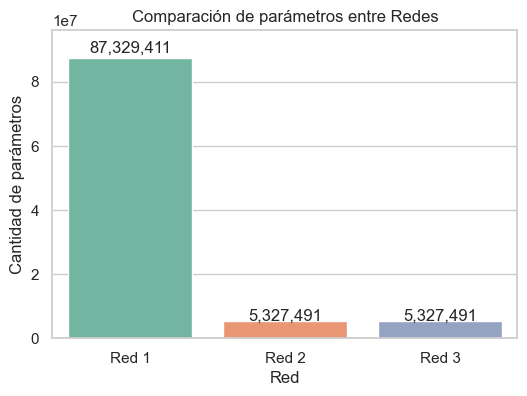

In [89]:
# Crear DataFrame para Seaborn
df = pd.DataFrame({
    'Red': ['Red 1', 'Red 2','Red 3'],
    'Cantidad de parámetros': [total_params1, total_params2,total_params3]
})

# Gráfico de barras
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Red', y='Cantidad de parámetros', hue='Red', palette='Set2', legend=False)
plt.title('Comparación de parámetros entre Redes')
plt.ylim(0, max(df['Cantidad de parámetros']) * 1.1)

# Agregar valores encima de las barras
for i, row in df.iterrows():
    plt.text(i, row['Cantidad de parámetros'] * 1.02, f"{row['Cantidad de parámetros']:,}", ha='center')

plt.show()


* **Rendimiento**

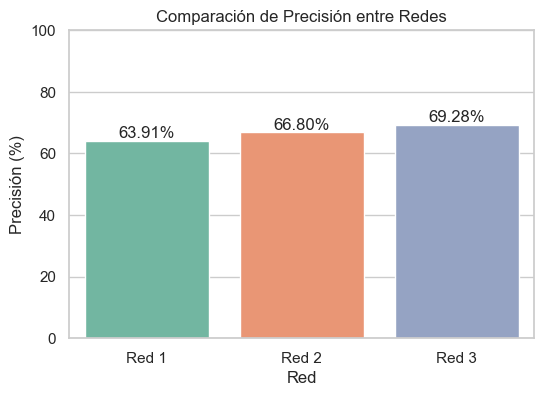

In [90]:
# Crear DataFrame para precisión (accuracy)
df_acc = pd.DataFrame({
    'Red': ['Red 1', 'Red 2','Red 3'],
    'Precisión (%)': [accuracy1 * 100, accuracy2 * 100, accuracy3*100]
})

plt.figure(figsize=(6,4))
sns.barplot(data=df_acc, x='Red', y='Precisión (%)', hue='Red', palette='Set2', legend=False)
plt.title('Comparación de Precisión entre Redes')
plt.ylim(0, 100)

for i, row in df_acc.iterrows():
    plt.text(i, row['Precisión (%)'] + 1, f"{row['Precisión (%)']:.2f}%", ha='center')

plt.show()

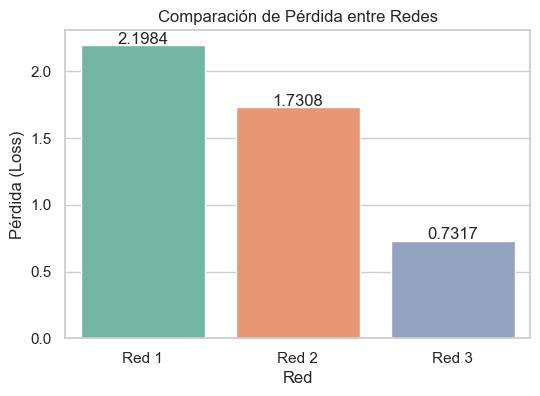

In [91]:
# Crear DataFrame para pérdida (loss)
df_loss = pd.DataFrame({
    'Red': ['Red 1', 'Red 2','Red 3'],
    'Pérdida (Loss)': [loss1, loss2, loss3]
})

plt.figure(figsize=(6,4))
sns.barplot(data=df_loss, x='Red', y='Pérdida (Loss)', hue='Red', palette='Set2', legend=False)
plt.title('Comparación de Pérdida entre Redes')

for i, row in df_loss.iterrows():
    plt.text(i, row['Pérdida (Loss)'] + 0.01, f"{row['Pérdida (Loss)']:.4f}", ha='center')

plt.show()

## Conclusiones


El análisis de los dos primeros modelos de redes neuronales convolucionales revela que ambos sufren de sobreajuste, aunque con diferentes grados y características. El primer modelo, muy complejo y con un gran número de parámetros, mostró un entrenamiento casi perfecto, pero falló en generalizar, obteniendo un desempeño limitado en validación y un alto costo computacional. En cambio, el segundo modelo, más sencillo y eficiente, logró reducir considerablemente el tiempo de entrenamiento gracias a la inclusión de capas MaxPooling (model2.add(layers.MaxPool2D((2,2), strides=2, padding='same'))), que ayudan a disminuir la dimensionalidad de los datos procesados. A pesar de mantener una precisión similar en validación, este modelo también presentó dificultades para generalizar adecuadamente, como lo indica la tendencia creciente de la pérdida de validación, porlo que estos resultados iniciales indican que la complejidad del modelo debe estar balanceada con la capacidad del conjunto de datos para evitar el sobreajuste. Además, resaltan la importancia de aplicar técnicas de regularización y otros métodos que favorezcan una mejor generalización.